# Taller: Auditoría de Desempeño para Negocios Digitales
## Estudiante: Matthew Ezequiel Llerena Montoya
## Paralelo: GR1CD
## Fecha: 19-06-2026
# Parte 1: Análisis de datos sintéticos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

# Muestro los primeros 5 datos solo para comprobar que el data frame se creó
df.head()

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,App Móvil,Transferencia,66,Moda
1,1002,App Móvil,PayPal,279,Electrónica
2,1003,Web Desktop,Transferencia,179,Hogar
3,1004,App Móvil,Tarjeta Crédito,308,Moda
4,1005,App Móvil,Transferencia,392,Moda


# Primer KPI
## Rentabilidad
En este KPI lo que vamos a visualizar es la suma del dinero que ingresó por la web y por otra parte todo lo que ingresó por la app para ver cuál generó mayores ventas

Ingresos totales por canal en dólares:
Canal
App Móvil      7717
Web Desktop    6296


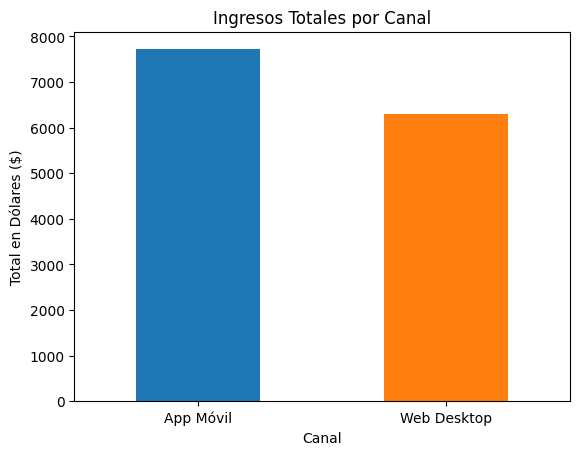

In [2]:
# Agrupamos por canal y sumamos el total de ventas
ingresos = df.groupby('Canal')['Total_Venta'].sum()

print("Ingresos totales por canal en dólares:")

# usamos .to_string() para ocultar el Name y el dtype
print(ingresos.to_string())

# Creamos la gráfica usando la libreria "matplotlib.pyplot"
ingresos.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Ingresos Totales por Canal')
plt.ylabel('Total en Dólares ($)')
plt.xlabel('Canal')
plt.xticks(rotation=0)
plt.show()

# Segundo KPI
## Ticket promedio por canal
Existe un caso en el que puede que hayan pocas transacciones o pocas ventas, pero eso no significa que se haya generado poco dinero, por lo que en este KPI lo que se busca es calcular el promedio de gasto por cada compra en cada canal

Ticket promedio por canal en dolares:
Canal
App Móvil      308.68
Web Desktop    251.84


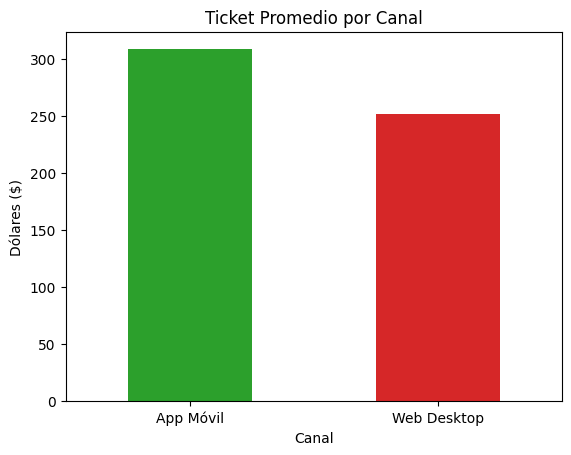

In [3]:
# Agrupamos por canal y sacamos el promedio (mean), redondeando a 2 decimales
ticket_promedio = df.groupby('Canal')['Total_Venta'].mean().round(2)
print("Ticket promedio por canal en dolares:")
print(ticket_promedio.to_string())


# Creamos la gráfica usando la libreria "matplotlib.pyplot"
ticket_promedio.plot(kind='bar', color=['#2ca02c', '#d62728'])
plt.title('Ticket Promedio por Canal')
plt.ylabel('Dólares ($)')
plt.xlabel('Canal')
plt.xticks(rotation=0)
plt.show()

# Tercer KPI
## Transacciones totales por cada canal
Con este KPI se busca analizar cual fue el canal más usado, si la App móvil o el Web, con el objetivo de ver cual es el más rentable para poder estar más atento a ese canal y que clientes de ese mismo medio reciban una buena experiencia y que se siga manteniendo el uso.

Cantidad de ventas:
Canal
App Móvil      25
Web Desktop    25


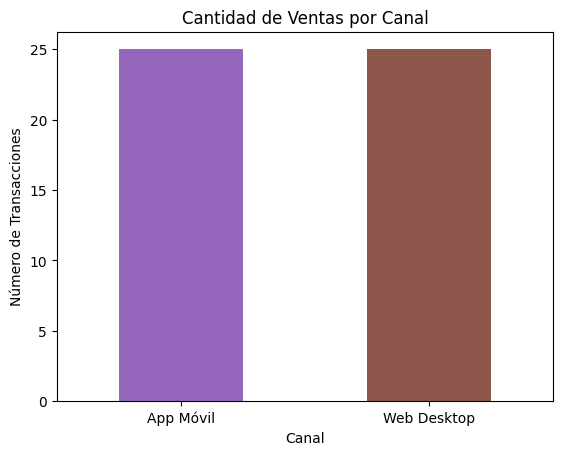

In [4]:
# Contamos cuántos IDs de transacción hay en cada canal
volumen = df.groupby('Canal')['ID_Transaccion'].count()
print("Cantidad de ventas:")
print(volumen.to_string())


# Creamos la gráfica usando la libreria "matplotlib.pyplot"
volumen.plot(kind='bar', color=['#9467bd', '#8c564b'])
plt.title('Cantidad de Ventas por Canal')
plt.ylabel('Número de Transacciones')
plt.xlabel('Canal')
plt.xticks(rotation=0)
plt.show()

# Cuarto KPI
## Ingresos por Canal y Categoría
Con este KPI lo que queremos es que se muestre qué tipo de productos son los más rentables en cada plataforma. En qué plataforma se generó más ingresos con practicamente que los mismos productos.

Ingresos por Canal y Categoría en dolares:

Canal        Categoria  
App Móvil    Electrónica    1535
             Hogar          3227
             Moda           2955
Web Desktop  Electrónica    1703
             Hogar          2134
             Moda           2459


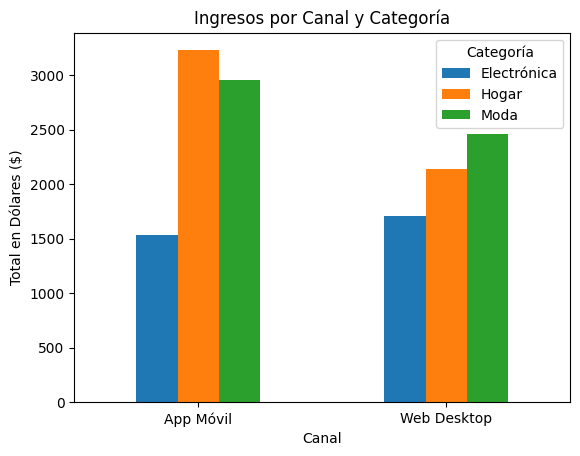

In [5]:
# Agrupamos por dos columnas para ver el detalle de rentabilidad por producto
categoria = df.groupby(['Canal', 'Categoria'])['Total_Venta'].sum()
print("Ingresos por Canal y Categoría en dolares:\n")
print(categoria.to_string())


# Creamos la gráfica usando la libreria "matplotlib.pyplot"
categoria.unstack().plot(kind='bar')
plt.title('Ingresos por Canal y Categoría')
plt.ylabel('Total en Dólares ($)')
plt.xlabel('Canal')
plt.xticks(rotation=0)
plt.legend(title='Categoría')
plt.show()

# Parte 2: KPIs para E-Commerce

In [6]:
data = pd.read_csv('/kaggle/input/datasets/matthewllerena/traincsv/Train.csv')
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## **1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)**
Permiten medir la eficiencia en la distribución de los productos electrónicos.

**1.1. Costo Promedio de Envío por Modo de Transporte (Mode of Shipment):** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

**1.2. Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

**1.3. Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

Costo Promedio por Modo de Transporte ($):
Mode_of_Shipment
Flight    209.31
Road      210.48
Ship      210.34

Volumen de Ocupación (Cantidad total de productos por bloque):
Warehouse_block
A    1833
B    1833
C    1833
D    1834
F    3666

Volumen de Ocupación (Peso total administrado en gramos):
Warehouse_block
A     6627118
B     6664240
C     6674560
D     6655305
F    13349327

Peso Promedio del Producto por Modo de Envío (gramos):
Mode_of_Shipment
Flight    3629.38
Road      3649.55
Ship      3631.46


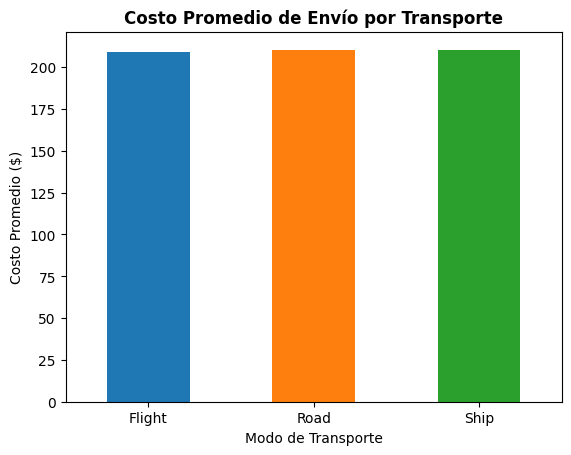

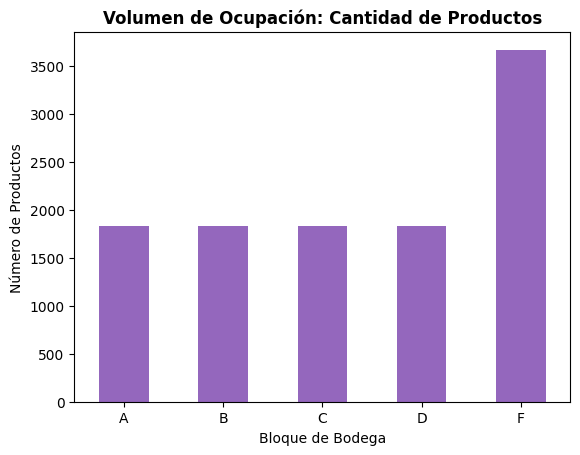

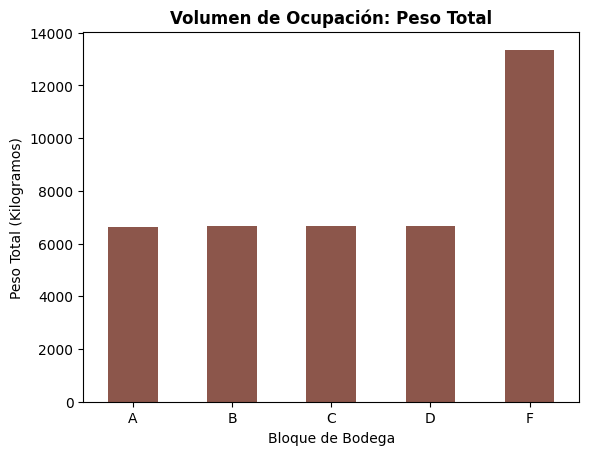

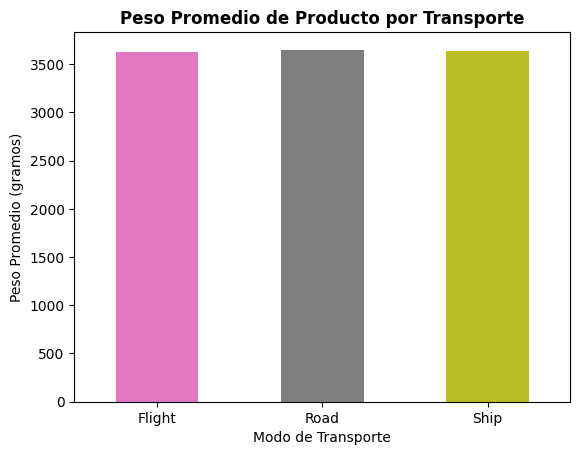

In [7]:
# agrupamos por modo de envío y sacamos el promedio del costo del producto
kpi1_1 = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().round(2)
print("Costo Promedio por Modo de Transporte ($):")
print(kpi1_1.to_string())

# Contamos cuántos productos hay en cada bloque usando el id:
kpi1_2_cantidad = data.groupby('Warehouse_block')['ID'].count()
print("\nVolumen de Ocupación (Cantidad total de productos por bloque):")
print(kpi1_2_cantidad.to_string())

# sumamos el peso total que administra cada bloque:
kpi1_2_peso = data.groupby('Warehouse_block')['Weight_in_gms'].sum()
print("\nVolumen de Ocupación (Peso total administrado en gramos):")
print(kpi1_2_peso.to_string())

# agrupamos por modo de envío y sacamos el promedio del peso
kpi1_3 = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().round(2)
print("\nPeso Promedio del Producto por Modo de Envío (gramos):")
print(kpi1_3.to_string())


kpi1_1.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Costo Promedio de Envío por Transporte', fontsize=12, fontweight='bold')
plt.ylabel('Costo Promedio ($)')
plt.xlabel('Modo de Transporte')
plt.xticks(rotation=0)
plt.show()

kpi1_2_cantidad.plot(kind='bar', color='#9467bd')
plt.title('Volumen de Ocupación: Cantidad de Productos', fontsize=12, fontweight='bold')
plt.ylabel('Número de Productos')
plt.xlabel('Bloque de Bodega')
plt.xticks(rotation=0)
plt.show()

(kpi1_2_peso / 1000).plot(kind='bar', color='#8c564b')
plt.title('Volumen de Ocupación: Peso Total', fontsize=12, fontweight='bold')
plt.ylabel('Peso Total (Kilogramos)')
plt.xlabel('Bloque de Bodega')
plt.xticks(rotation=0)
plt.show()

kpi1_3.plot(kind='bar', color=['#e377c2', '#7f7f7f', '#bcbd22'])
plt.title('Peso Promedio de Producto por Transporte', fontsize=12, fontweight='bold')
plt.ylabel('Peso Promedio (gramos)')
plt.xlabel('Modo de Transporte')
plt.xticks(rotation=0)
plt.show()

## **2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)**
Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

**2.1. Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable Cost of the product para entender el ticket promedio de la tienda de electrónica.

**2.2. Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (Discount offered) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

**2.3. Margen Teórico Relativo por Importancia del Producto:** Cruzar Product importance (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.


Ingreso Total Bruto de la tienda: $2311955
Costo Promedio del Producto (Ticket Promedio): $210.2

Descuento Promedio según la cantidad de Compras Previas (%):
Prior_purchases
2     15.32
3     14.98
4     10.85
5      9.27
6     11.06
7     17.53
8     13.32
10    13.60

Costo Promedio ($) y Descuento Promedio (%) por Importancia del Producto:
                    Cost_of_the_Product  Discount_offered
Product_importance                                       
high                             203.87             14.67
low                              212.06             13.04
medium                           209.38             13.48


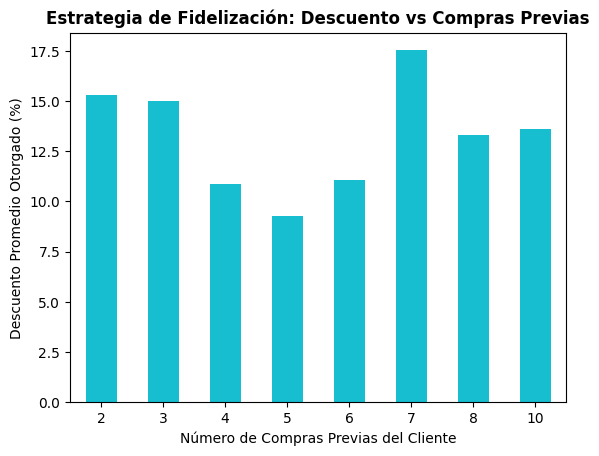

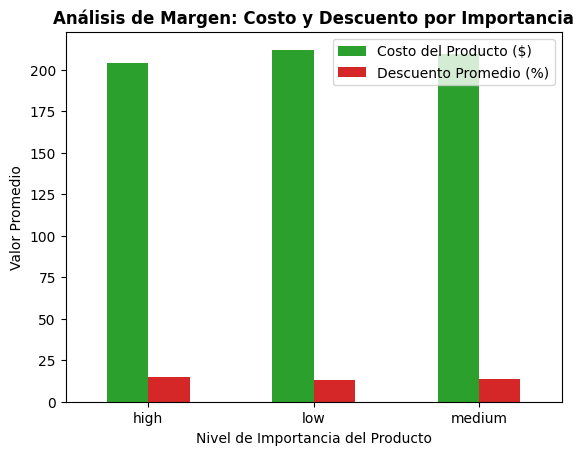

In [8]:
# sacamos la suma y el promedio de toda la columna
kpi2_1_ingreso_total = data['Cost_of_the_Product'].sum()
kpi2_1_costo_promedio = data['Cost_of_the_Product'].mean().round(2)

print(f"\nIngreso Total Bruto de la tienda: ${kpi2_1_ingreso_total}")
print(f"Costo Promedio del Producto (Ticket Promedio): ${kpi2_1_costo_promedio}")

# Agrupamos por cantidad de compras previas para ver si a los clientes más fieles se les da más descuento
kpi2_2_descuento = data.groupby('Prior_purchases')['Discount_offered'].mean().round(2)

print("\nDescuento Promedio según la cantidad de Compras Previas (%):")
print(kpi2_2_descuento.to_string())

# Pasamos una lista con dos columnas para calcular el promedio de ambas simultáneamente
kpi2_3_margen = data.groupby('Product_importance')[['Cost_of_the_Product', 'Discount_offered']].mean().round(2)

print("\nCosto Promedio ($) y Descuento Promedio (%) por Importancia del Producto:")
print(kpi2_3_margen.to_string())


kpi2_2_descuento.plot(kind='bar', color='#17becf')
plt.title('Estrategia de Fidelización: Descuento vs Compras Previas', fontsize=12, fontweight='bold')
plt.ylabel('Descuento Promedio Otorgado (%)')
plt.xlabel('Número de Compras Previas del Cliente')
plt.xticks(rotation=0)
plt.show()

kpi2_3_margen.plot(kind='bar', color=['#2ca02c', '#d62728'])
plt.title('Análisis de Margen: Costo y Descuento por Importancia', fontsize=12, fontweight='bold')
plt.ylabel('Valor Promedio')
plt.xlabel('Nivel de Importancia del Producto')
plt.xticks(rotation=0)
plt.legend(['Costo del Producto ($)', 'Descuento Promedio (%)'])
plt.show()

## **3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)**
Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

**3.1. Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable Customer rating (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

**3.2. Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de Prior purchases para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

**3.3. Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

CSAT Promedio por Bloque de Bodega (Escala 1-5):
Warehouse_block
A    2.96
B    2.98
C    2.99
D    3.02
F    3.00

Clientes Nuevos (0-1 compras previas): 0.0%
Clientes Fidelizados (2 o más compras): 100.0%

Promedio de Llamadas de Soporte según la Calificación del Cliente:
Customer_rating
1    4.04
2    4.05
3    4.06
4    4.04
5    4.09


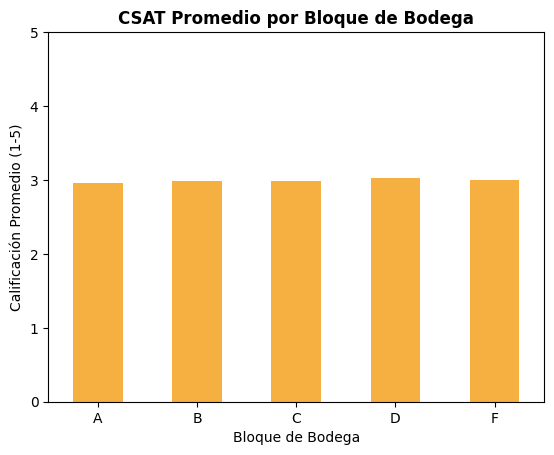

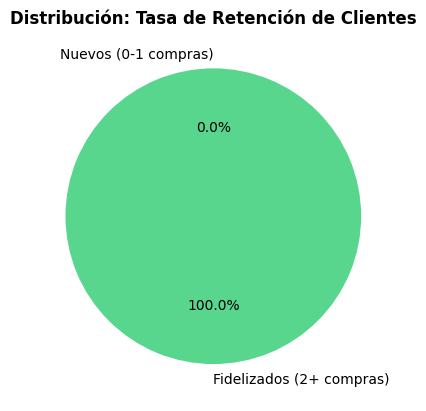

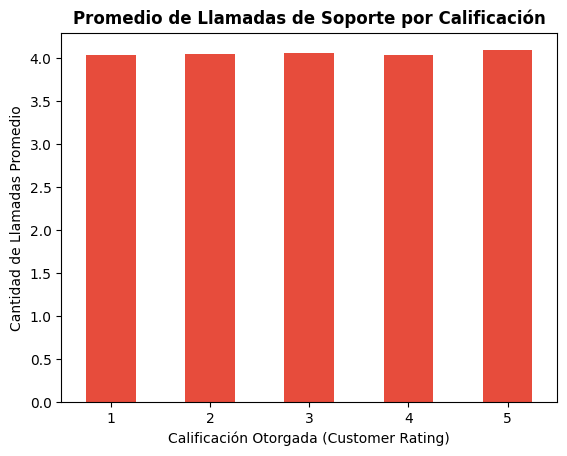

In [9]:
# CSAT Promedio por Bloque de Bodega
kpi3_1_csat = data.groupby('Warehouse_block')['Customer_rating'].mean().round(2)
print("CSAT Promedio por Bloque de Bodega (Escala 1-5):")
print(kpi3_1_csat.to_string())

# Tasa de Retención / Clientes Recurrentes
total_clientes = len(data)
clientes_nuevos = len(data[data['Prior_purchases'] <= 1])
clientes_recurrentes = len(data[data['Prior_purchases'] >= 2])

porcentaje_nuevos = (clientes_nuevos / total_clientes) * 100
porcentaje_recurrentes = (clientes_recurrentes / total_clientes) * 100

print(f"\nClientes Nuevos (0-1 compras previas): {porcentaje_nuevos:.1f}%")
print(f"Clientes Fidelizados (2 o más compras): {porcentaje_recurrentes:.1f}%")

# Carga de Soporte por Calificación del Cliente
kpi3_3_soporte = data.groupby('Customer_rating')['Customer_care_calls'].mean().round(2)
print("\nPromedio de Llamadas de Soporte según la Calificación del Cliente:")
print(kpi3_3_soporte.to_string())



kpi3_1_csat.plot(kind='bar', color='#f5b041')
plt.title('CSAT Promedio por Bloque de Bodega', fontweight='bold')
plt.ylabel('Calificación Promedio (1-5)')
plt.xlabel('Bloque de Bodega')
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.show()

plt.pie([clientes_nuevos, clientes_recurrentes], 
        labels=['Nuevos (0-1 compras)', 'Fidelizados (2+ compras)'], 
        autopct='%1.1f%%', 
        colors=['#5dade2', '#58d68d'], 
        startangle=90)
plt.title('Distribución: Tasa de Retención de Clientes', fontweight='bold')
plt.show()

kpi3_3_soporte.plot(kind='bar', color='#e74c3c')
plt.title('Promedio de Llamadas de Soporte por Calificación', fontweight='bold')
plt.ylabel('Cantidad de Llamadas Promedio')
plt.xlabel('Calificación Otorgada (Customer Rating)')
plt.xticks(rotation=0)
plt.show()